# **Morphological Operators in Digital Image Processing**

* Introduction to Morphological Operators
* Types of Morphological Operators
    * Dilation
    * Erosion
    * Opening
    * Closing
    * Morphological Gradient
    * Top-Hat and Bottom-Hat Transformations
    * Skeletonization
* Practical Applications
* Code Implementations
* References


## **Introduction to Morphological Operators**

Morphological operators are powerful tools in digital image processing that operate on the shape or structure of objects within an image. Based on mathematical morphology, these operators use a structuring element to probe and modify the geometry of image features, making them particularly useful for tasks like noise reduction, object segmentation, and feature extraction [1]. Morphological operators are widely applied in fields such as medical imaging, industrial inspection, and computer vision as of 12:33 PM IST on Sunday, June 22, 2025.

### Why Necessary:
1. **Shape Analysis**: Morphological operators analyze and manipulate object shapes, enabling tasks like boundary detection and region filling [1].
2. **Noise Reduction**: Techniques like opening and closing remove noise while preserving object structures [3].
3. **Segmentation**: Morphological operators facilitate the separation of objects from backgrounds, crucial for medical diagnostics [4].
4. **Feature Extraction**: They highlight specific structural features, such as edges or skeletons, for further analysis [1].
5. **Preprocessing**: Morphological operations prepare images for advanced tasks like object recognition and classification [3].
6. **Robustness**: These operators are effective on binary and grayscale images, offering versatility across applications [1].


## **What Are Morphological Operators?**

* <font color="green">Morphological operators are non-linear image processing techniques that modify pixel values based on the local geometry defined by a structuring element [1].</font>
* A structuring element is a small shape (e.g., square, disk, or cross) that probes the image, determining how the operator interacts with pixel neighborhoods.
* <font color="green">These operators are particularly effective for enhancing or suppressing specific image features, making them suitable for applications like tumor detection in medical imaging or defect identification in industrial imaging [4].</font>
    * The choice of structuring element size and shape is application-specific, e.g., a larger structuring element may be used for coarse features in X-ray images compared to fine details in retinal scans [3].


## **Types of Morphological Operators**

<font color="green">Morphological operators manipulate image structures in the spatial domain using set theory principles [1].</font>

* **Dilation**: Expands object boundaries by adding pixels to the edges, filling small gaps [1].
* **Erosion**: Shrinks object boundaries by removing pixels from the edges, eliminating small noise [1].
* **Opening**: Erosion followed by dilation, smooths object contours and removes small objects [3].
* **Closing**: Dilation followed by erosion, fills small holes and connects nearby objects [3].
* **Morphological Gradient**: Difference between dilation and erosion, highlights object boundaries [1].
* **Top-Hat and Bottom-Hat Transformations**: Extract bright or dark features relative to the background [3].
* **Skeletonization**: Reduces objects to a single-pixel-wide representation, preserving topology [1].
* **The Hit-or-Miss Transform**: Detects specific patterns or shapes using a pair of structuring elements [2].


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## **Dilation**

Dilation is a fundamental morphological operation that enlarges the boundaries of objects in an image. It involves sliding a structuring element over the image and assigning the maximum value (for grayscale) or union (for binary) within the structuring element's neighborhood to the output pixel.

**Key Concept**

* Objective: Expand object regions to fill gaps or connect disjointed parts, improving object continuity [1].
* Assumption: Dilation assumes that the structuring element defines the shape and extent of expansion [3].
* Mechanism: For a binary image, dilation sets a pixel to 1 if any pixel in the structuring element's neighborhood is 1. For grayscale images, it takes the maximum intensity value within the neighborhood [1].


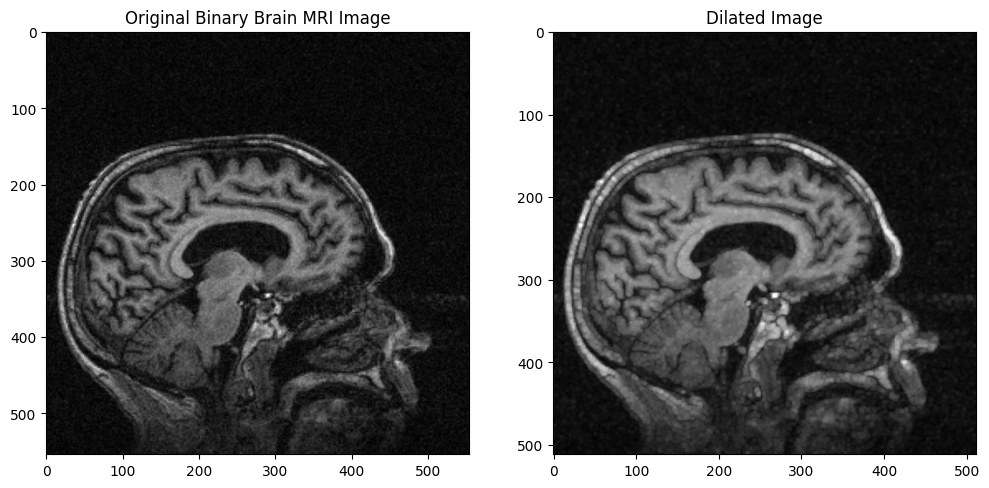

In [27]:

img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply dilation
img_dilated = cv2.dilate(img_resize, kernel, iterations=1)

# Save the result
cv2.imwrite('Dilation/dilated_binary_Brain_MRI.jpg', img_dilated)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_org, cmap='gray'); plt.title('Original Binary Brain MRI Image')
plt.subplot(122); plt.imshow(img_dilated, cmap='gray'); plt.title('Dilated Image')
plt.show()


## **Erosion**

Erosion is a morphological operation that shrinks the boundaries of objects by removing pixels from the edges. It uses a structuring element to probe the image and assigns the minimum value (for grayscale) or intersection (for binary) within the neighborhood to the output pixel.

**Key Concept**

* Objective: Reduce object size to remove noise or isolate specific regions [1].
* Assumption: Erosion assumes the structuring element defines the extent of shrinkage [3].
* Mechanism: For a binary image, a pixel is set to 0 unless all pixels in the structuring element's neighborhood are 1. For grayscale, it takes the minimum intensity value [1].


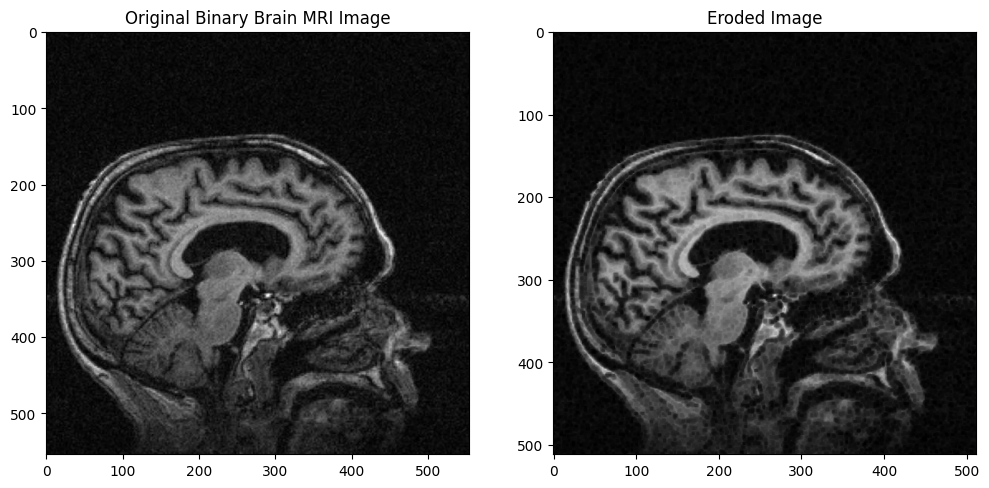

In [28]:
# Load a binary satellite image with urban features
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply erosion
img_eroded = cv2.erode(img_resize, kernel, iterations=1)

# Save the result
cv2.imwrite('Erosion/eroded_binary_Brain MRI.jpg', img_eroded)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_org, cmap='gray'); plt.title('Original Binary Brain MRI Image')
plt.subplot(122); plt.imshow(img_eroded, cmap='gray'); plt.title('Eroded Image')
plt.show()


## **Opening**

Opening is a two-step morphological operation that involves erosion followed by dilation. It smooths object contours, removes small objects, and breaks narrow connections while preserving the overall shape of larger objects.

**Key Concept**

* Objective: Remove noise and small artifacts while maintaining larger structures [3].
* Assumption: The structuring element size determines the scale of noise to be removed [1].
* Mechanism: Erosion first shrinks the image, then dilation restores the shape, eliminating small features [3].


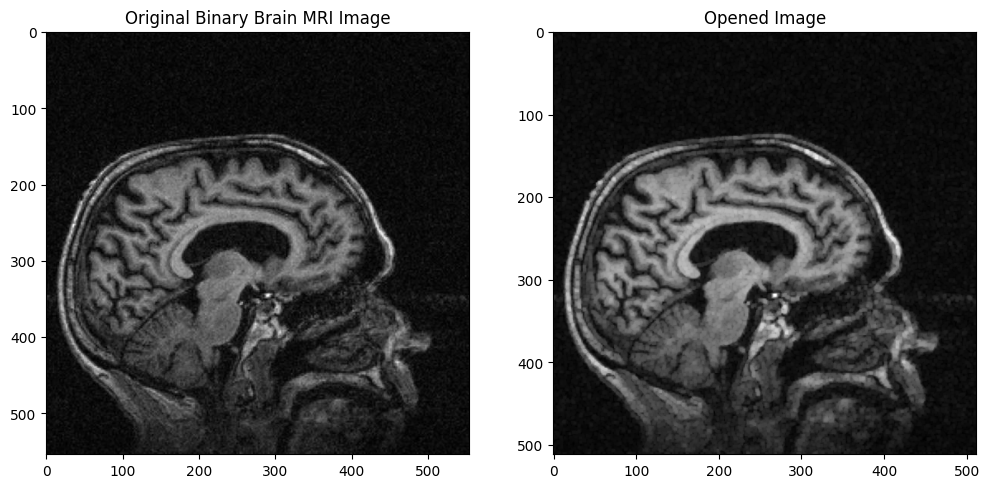

In [29]:
# Load a binary satellite image with urban features
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply opening
img_opened = cv2.morphologyEx(img_resize, cv2.MORPH_OPEN, kernel)

# Save the result
cv2.imwrite('Opening/opened_binary_Brain_MRI.jpg', img_opened)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_org, cmap='gray'); plt.title('Original Binary Brain MRI Image')
plt.subplot(122); plt.imshow(img_opened, cmap='gray'); plt.title('Opened Image')
plt.show()


## **Closing**

Closing is a two-step morphological operation that involves dilation followed by erosion. It fills small holes, connects nearby objects, and smooths boundaries while preserving the overall shape.

**Key Concept**

* Objective: Close gaps and connect disjointed regions while removing small holes [3].
* Assumption: The structuring element size defines the scale of gaps to be filled [1].
* Mechanism: Dilation first expands the image, then erosion restores the shape, closing small gaps [3].


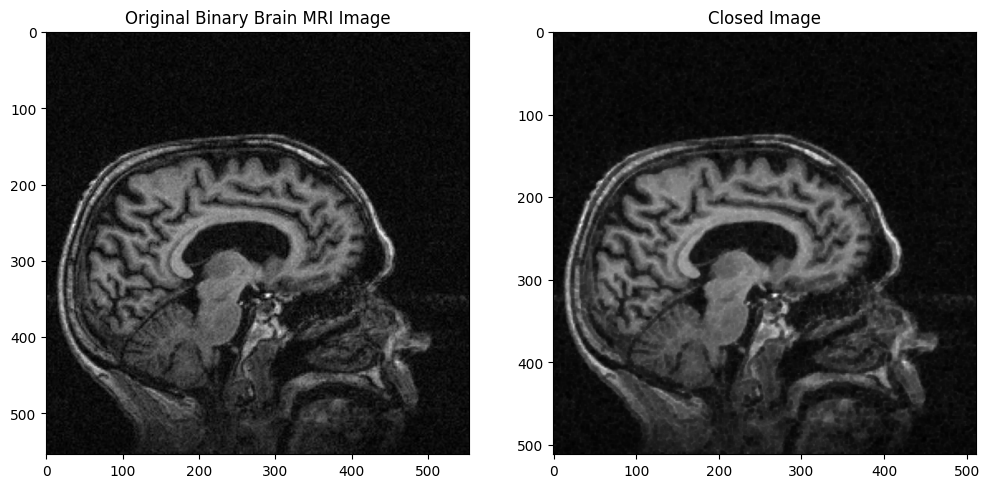

In [31]:
# Load a binary satellite image with urban features
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply closing
img_closed = cv2.morphologyEx(img_resize, cv2.MORPH_CLOSE, kernel)

# Save the result
cv2.imwrite('Closing/closed_binary_Brain_MRI.jpg', img_closed)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_org, cmap='gray'); plt.title('Original Binary Brain MRI Image')
plt.subplot(122); plt.imshow(img_closed, cmap='gray'); plt.title('Closed Image')
plt.show()


## **Morphological Gradient**

The morphological gradient is the difference between the dilation and erosion of an image. It highlights the boundaries or edges of objects by emphasizing the rate of change in intensity.

**Key Concept**

* Objective: Detect edges and boundaries of objects [1].
* Assumption: The gradient magnitude reflects the structural changes [3].
* Mechanism: Subtracting the eroded image from the dilated image produces the gradient [1].


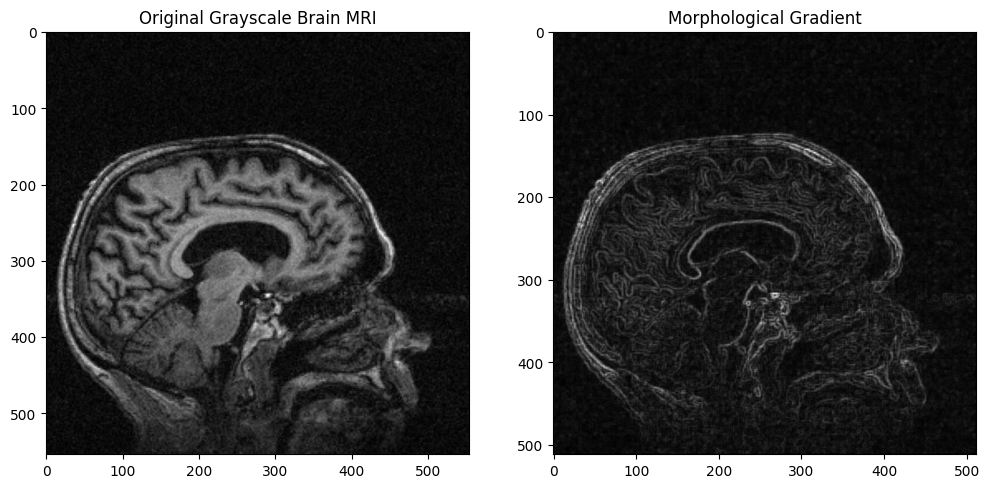

In [33]:
# Load a grayscale 
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply morphological gradient
img_gradient = cv2.morphologyEx(img_resize, cv2.MORPH_GRADIENT, kernel)

# Save the result
cv2.imwrite('Morphological_Gradient/Original_Brain_MRI.jpg', img_org)
cv2.imwrite('Morphological_Gradient/gradient_grayscale_Brain_MRI.jpg', img_gradient)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_org, cmap='gray'); plt.title('Original Grayscale Brain MRI')
plt.subplot(122); plt.imshow(img_gradient, cmap='gray'); plt.title('Morphological Gradient')
plt.show()


## **Top-Hat and Bottom-Hat Transformations**

Top-Hat transformation extracts small bright regions against a darker background, while Bottom-Hat transformation extracts small dark regions against a brighter background. Both use the original image and its opening or closing.

**Key Concept**

* Objective: Enhance contrast by isolating bright or dark features [3].
* Assumption: The structuring element size determines the scale of features to extract [1].
* Mechanism: Top-Hat is the difference between the original image and its opening; Bottom-Hat is the difference between its closing and the original image [3].


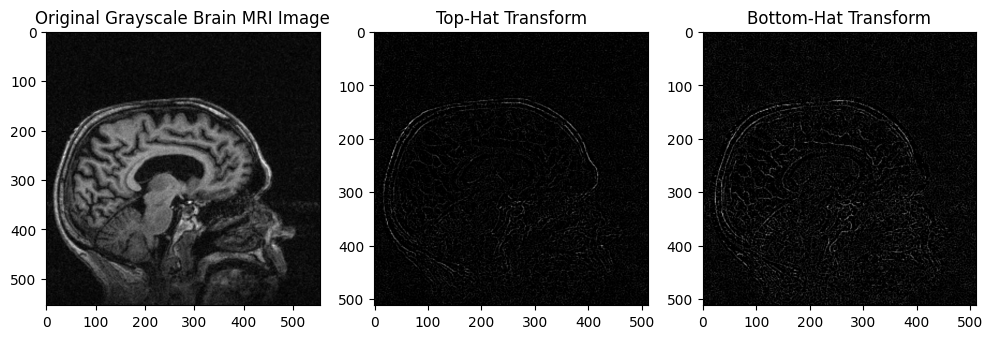

In [34]:

# Load a grayscale satellite image with land cover
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply Top-Hat and Bottom-Hat transformations
img_tophat = cv2.morphologyEx(img_resize, cv2.MORPH_TOPHAT, kernel)
img_bothat = cv2.morphologyEx(img_resize, cv2.MORPH_BLACKHAT, kernel)

# Save the results
cv2.imwrite('TH_BH_Transformation/tophat_grayscale_Brain_MRI.jpg', img_tophat)
cv2.imwrite('TH_BH_Transformation/bothat_grayscale_Brain_MRI.jpg', img_bothat)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(131); plt.imshow(img_org, cmap='gray'); plt.title('Original Grayscale Brain MRI Image')
plt.subplot(132); plt.imshow(img_tophat, cmap='gray'); plt.title('Top-Hat Transform')
plt.subplot(133); plt.imshow(img_bothat, cmap='gray'); plt.title('Bottom-Hat Transform')
plt.show()


## **Skeletonization**

Skeletonization reduces objects to a single-pixel-wide representation while preserving their topology. It iteratively applies erosion and checks for connectivity to avoid breaking the structure.

**Key Concept**

* Objective: Simplify objects into their skeletal form for shape analysis [1].
* Assumption: The process preserves the essential shape and connectivity [3].
* Mechanism: Uses iterative erosion with hit-or-miss transforms to thin objects [1].


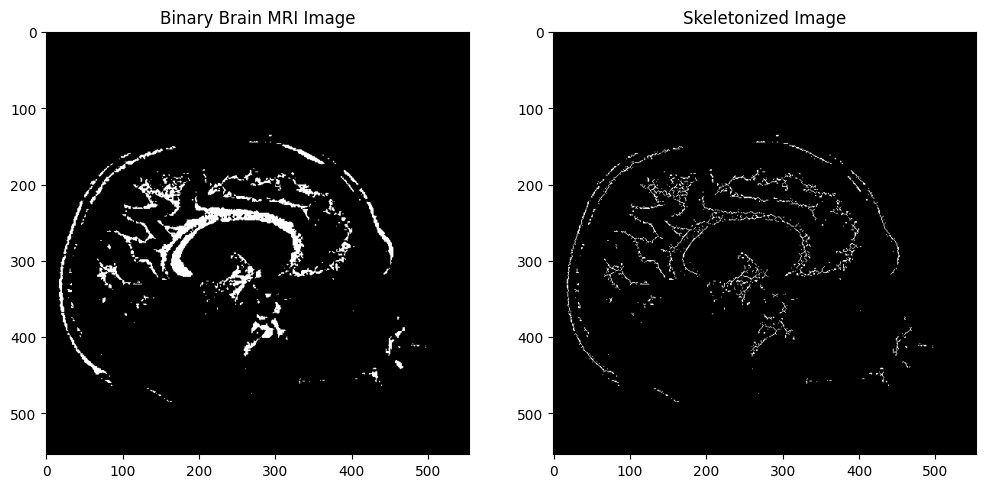

In [37]:

img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
_, img_binary = cv2.threshold(img_org, 127, 255, cv2.THRESH_BINARY)

# Define a structuring element
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

#img_skeleton = np.zeros(img_binary.shape, np.uint8)
img_temp = img_binary.copy()

while True:
    eroded = cv2.erode(img_temp, kernel)
    opened = cv2.dilate(eroded, kernel)
    temp = cv2.subtract(img_temp, opened)
    img_skeleton = cv2.bitwise_or(img_skeleton, temp)
    img_temp = eroded.copy()
    if cv2.countNonZero(img_temp) == 0:
        break

# Save the result
cv2.imwrite('Skeletonization/skeleton_binary_Brain_MRI.jpg', img_skeleton)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_binary, cmap='gray'); plt.title('Binary Brain MRI Image')
plt.subplot(122); plt.imshow(img_skeleton, cmap='gray'); plt.title('Skeletonized Image')
plt.show()

## **The Hit-or-Miss Transform**

The Hit-or-Miss Transform is a morphological operation that detects specific patterns or shapes in a binary image using a pair of structuring elements: one for the foreground (hit) and one for the background (miss).

**Key Concept**

* Objective: Identify predefined shapes or configurations, such as corners or endpoints [2].
* Assumption: The structuring elements accurately represent the pattern to detect [1].
* Mechanism: The transform matches the foreground element where the image matches and the background element where it does not, producing a binary output [2].


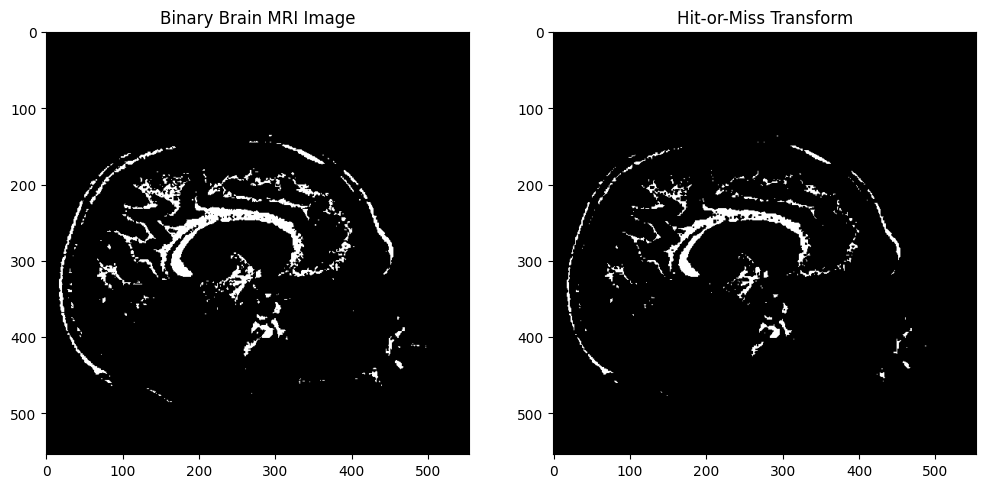

In [38]:

img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
_, img_binary = cv2.threshold(img_org, 127, 255, cv2.THRESH_BINARY)

# Define structuring elements for Hit-or-Miss (e.g., detect a corner)
kernel_hit = np.array([[1, 1, 0],
                      [1, 1, 0],
                      [0, 0, 0]], dtype=np.uint8)
kernel_miss = np.array([[0, 0, 1],
                       [0, 0, 1],
                       [1, 1, 1]], dtype=np.uint8)

# Apply Hit-or-Miss Transform
img_hitmiss = cv2.morphologyEx(img_binary, cv2.MORPH_HITMISS, kernel_hit)

# Save the result
cv2.imwrite('Hit_or_Miss_Transform/hitmiss_binary_satellite_urban.jpg', img_hitmiss)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_binary, cmap='gray'); plt.title('Binary Brain MRI Image')
plt.subplot(122); plt.imshow(img_hitmiss, cmap='gray'); plt.title('Hit-or-Miss Transform')
plt.show()


## **Some Basic Morphological Algorithms**

Basic morphological algorithms combine operators to solve specific image processing tasks, such as noise removal, boundary extraction, or region filling.

**Key Concept**

* Objective: Automate common tasks using sequences of morphological operations [3].
* Assumption: The sequence of operations is tailored to the image content and goal [1].
* Mechanism: Algorithms may include iterative applications of opening/closing or custom workflows [3].

**Example Algorithm: Noise Removal and Boundary Extraction**
- Step 1: Apply opening to remove small noise.
- Step 2: Apply morphological gradient to extract boundaries.


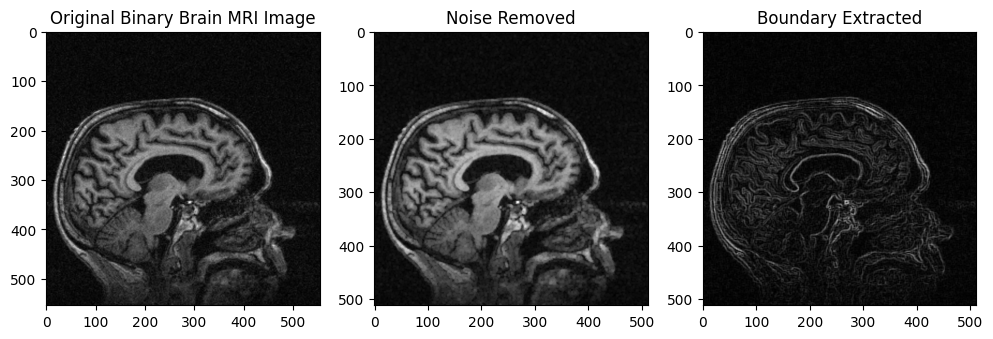

In [39]:
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Step 1: Apply opening to remove noise
img_opened = cv2.morphologyEx(img_resize, cv2.MORPH_OPEN, kernel)

# Step 2: Apply morphological gradient to extract boundaries
img_gradient = cv2.morphologyEx(img_opened, cv2.MORPH_GRADIENT, kernel)

# Save the results
cv2.imwrite('Morphological_Results/opened_binary_Brain_MRI.jpg', img_opened)
cv2.imwrite('Morphological_Results/gradient_opened_binary_Brain_MRI.jpg', img_gradient)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(131); plt.imshow(img_org, cmap='gray'); plt.title('Original Binary Brain MRI Image')
plt.subplot(132); plt.imshow(img_opened, cmap='gray'); plt.title('Noise Removed')
plt.subplot(133); plt.imshow(img_gradient, cmap='gray'); plt.title('Boundary Extracted')
plt.show()


## **Morphological Reconstruction**

Morphological reconstruction refines an image by iteratively applying dilation or erosion under a marker image, reconstructing shapes or regions while preserving connectivity.

**Key Concept**

* Objective: Reconstruct or enhance regions based on a marker, useful for filling holes or segmenting objects [3].
* Assumption: The marker defines the starting region for reconstruction [1].
* Mechanism: Iterative dilation of the marker constrained by the original image [3].


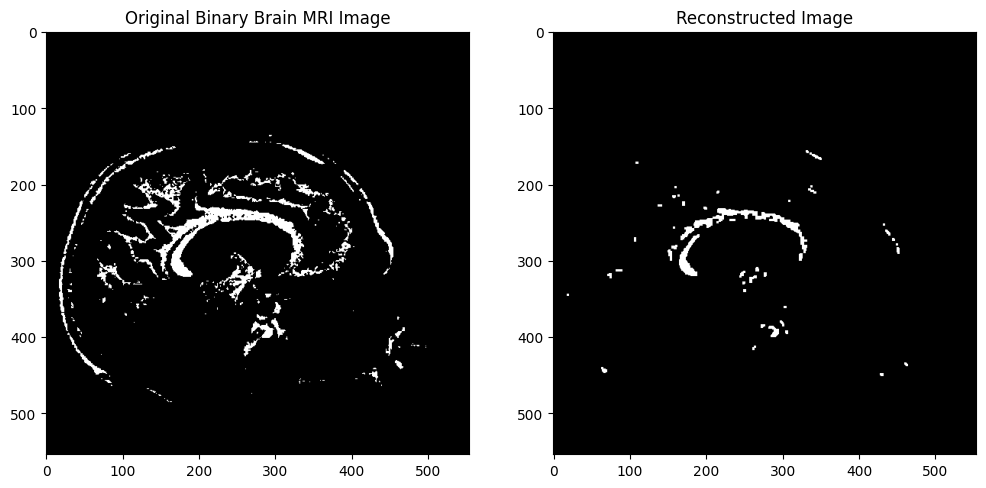

In [40]:
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
_, img_binary = cv2.threshold(img_org, 127, 255, cv2.THRESH_BINARY)

# Create a marker image (e.g., a subset of the original)
marker = cv2.erode(img_binary, np.ones((5, 5), np.uint8), iterations=1)

# Apply morphological reconstruction by iterative dilation
reconstructed = marker.copy()
while True:
    dilated = cv2.dilate(reconstructed, np.ones((3, 3), np.uint8))
    reconstructed = cv2.min(dilated, img_binary)
    if (dilated == reconstructed).all():
        break

# Save the result
cv2.imwrite('Morphological_Reconstruction/reconstructed_binary_Brain_MRI.jpg', reconstructed)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(121); plt.imshow(img_binary, cmap='gray'); plt.title('Original Binary Brain MRI Image')
plt.subplot(122); plt.imshow(reconstructed, cmap='gray'); plt.title('Reconstructed Image')
plt.show()


## **Summary of Morphological Operations on Binary Images**

Morphological operations on binary images are essential for shape analysis and preprocessing. Key operations include:
- **Dilation and Erosion**: Modify object size and connectivity.
- **Opening and Closing**: Remove noise and fill gaps.
- **Hit-or-Miss Transform**: Detect specific patterns.
- **Skeletonization**: Reduce to skeletal form.
- **Morphological Reconstruction**: Enhance region connectivity.

These operations rely on binary thresholding and structuring elements, making them efficient for tasks like urban mapping or object counting [1].


## **Grayscale Morphology**

Grayscale morphology extends binary operations to images with intensity values, using the same principles but operating on pixel intensities.

**Key Concept**

* Objective: Enhance or suppress grayscale features like ridges or valleys [3].
* Assumption: Intensity variations define object boundaries and textures [1].
* Mechanism: Dilation takes the maximum, erosion the minimum, within the structuring element's neighborhood [3].

**Applications**: Noise reduction in satellite imagery, edge detection in terrain maps.


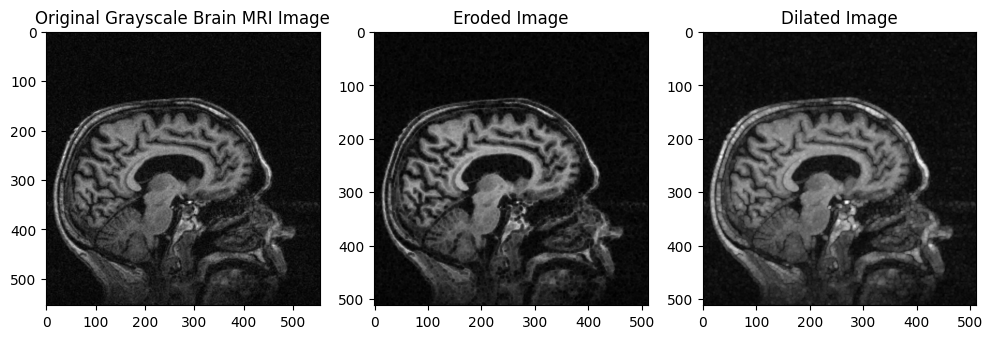

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a grayscale satellite image with land cover
img_org = cv2.imread('OAS2_0001_MR2_z_slice_129.jpg', cv2.IMREAD_GRAYSCALE)
img_resize = cv2.resize(img_org, (512, 512))

# Define a structuring element (3x3 square)
kernel = np.ones((3, 3), np.uint8)

# Apply grayscale erosion and dilation
img_eroded = cv2.erode(img_resize, kernel, iterations=1)
img_dilated = cv2.dilate(img_resize, kernel, iterations=1)

# Save the results
cv2.imwrite('Grayscale_Morphology/eroded_grayscale_Brain_MRI.jpg', img_eroded)
cv2.imwrite('Grayscale_Morphology/dilated_grayscale_Brain_MRI.jpg', img_dilated)

# Plot the images
plt.figure(figsize=(12, 8))
plt.subplot(131); plt.imshow(img_org, cmap='gray'); plt.title('Original Grayscale Brain MRI Image')
plt.subplot(132); plt.imshow(img_eroded, cmap='gray'); plt.title('Eroded Image')
plt.subplot(133); plt.imshow(img_dilated, cmap='gray'); plt.title('Dilated Image')
plt.show()


## **Practical Applications**

Morphological operators are extensively used across various domains [3]:

- **Medical Imaging**: Dilation and closing enhance tumor boundaries in brain MRIs, while opening removes noise in ultrasound images, aiding diagnosis [4].
- **Industrial Inspection**: Morphological gradient detects defects in circuit boards, and skeletonization simplifies shape analysis for quality control [1].
- **Satellite Imagery**: Opening and closing preprocess images for land cover classification, improving robustness against cloud noise [3].


## **References**

[1] R. C. Gonzalez and R. E. Woods, *Digital Image Processing*, 4th ed. Pearson, 2018.

[2] J. Serra, *Image Analysis and Mathematical Morphology*, Academic Press, 1982.

[3] P. Soille, *Morphological Image Analysis: Principles and Applications*, 2nd ed. Springer, 2004.

[4] S. Beucher and F. Meyer, "The morphological approach to segmentation: The watershed transformation," *Mathematical Morphology in Image Processing*, pp. 433--481, 1993.

[5] OpenCV, "OpenCV Documentation," [https://docs.opencv.org](https://docs.opencv.org), 2025.

[6] Kaggle, Images and Datasets.
